In [ ]:
#MOUNT TO GOOGLE DRIVE - UPLOAD THE DATASETS (IMP)
#COPY PATH OF DATASETS
#SPLIT_FOLDERS INTO SEPARATE IPYNB FILE IN GOOGLE DRIVE - USE SAME FOR ALL MODELS
#INCREASE EPOCHS
#ADD CONFUSION MATRIX
#CHANGE RUNTIME TYPE TO GPU
#ADD EARLY STOPPING TO MODEL.

In [ ]:
import pandas as pd
from pprint import pprint

import tensorflow as tf
from tensorflow.keras.models import Model
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions

In [ ]:
pip install split_folders

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import splitfolders
input_folder = '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Fruits'
splitfolders.ratio(input_folder,
                   output="fruit_images",
                   seed=42,
                   ratio=(.60, .2, .2),
                   group_prefix=None)
input_folder = '/content/drive/MyDrive/Colab Notebooks/Citrus /Citrus Dataset/Citrus/Leaves'
splitfolders.ratio(input_folder,
                   output="leaves_images",
                   seed=42,
                   ratio=(.60, .2, .2),
                   group_prefix=None)

Copying files: 493 files [04:05,  2.01 files/s]
Copying files: 985 files [01:53,  8.70 files/s]


[INFO] loading images...
['/content/fruit_images/train/greening/citrus fruit Greening 36.jpg', '/content/fruit_images/train/greening/citrus fruit Greening 1.jpg', '/content/fruit_images/train/greening/citrus fruit Greening 3.jpg', '/content/fruit_images/train/greening/Greening (6).jpg', '/content/fruit_images/train/greening/citrus fruit Greening 76.jpg', '/content/fruit_images/train/greening/citrus fruit Greening 46.jpg', '/content/fruit_images/train/greening/citrus fruit Greening 35.jpg', '/content/fruit_images/train/greening/citrus fruit Greening 71.jpg', '/content/fruit_images/train/greening/Greening (10).jpg', '/content/fruit_images/train/greening/citrus fruit Greening 54.jpg', '/content/fruit_images/train/greening/citrus fruit Greening 52.jpg', '/content/fruit_images/train/greening/citrus fruit Greening 80.jpg', '/content/fruit_images/train/greening/Greening (15).jpg', '/content/fruit_images/train/greening/citrus fruit Greening 16.jpg', '/content/fruit_images/train/greening/citrus

10/10 [==============================] - 7s 517ms/step - loss: 13.1265 - accuracy: 0.1667 - val_loss: 3.5631 - val_accuracy: 0.1649
Epoch 2/10
10/10 [==============================] - 2s 164ms/step - loss: 2.1645 - accuracy: 0.2891
Epoch 3/10
10/10 [==============================] - 2s 164ms/step - loss: 1.0767 - accuracy: 0.5782
Epoch 4/10
10/10 [==============================] - 2s 152ms/step - loss: 0.7366 - accuracy: 0.7415
Epoch 5/10
10/10 [==============================] - 2s 149ms/step - loss: 0.3349 - accuracy: 0.8980
Epoch 6/10
10/10 [==============================] - 2s 174ms/step - loss: 0.1665 - accuracy: 0.9660
Epoch 7/10
10/10 [==============================] - 2s 199ms/step - loss: 0.0888 - accuracy: 0.9796
Epoch 8/10
10/10 [==============================] - 2s 189ms/step - loss: 0.0521 - accuracy: 0.9864
Epoch 9/10
10/10 [==============================] - 2s 154ms/step - loss: 0.0450 - accuracy: 0.9898
Epoch 10/10
4/4 [==============================] - 1s 148ms/step - l

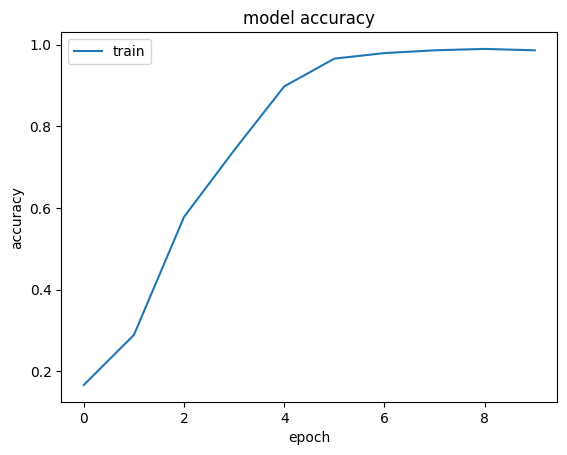

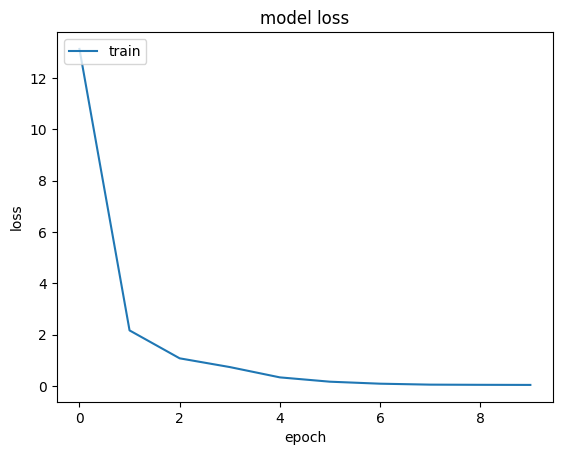

'\n# serialize the model to disk\nprint("[INFO] serializing network...")\nhistory.save("model1.h5")\n# serialize the label binarizer to disk\npkl_filename = "Pickle_model1.pkl"\nwith open(pkl_filename, \'wb\') as file:\n    pickle.dump(lb, file)\n'

<Figure size 640x480 with 0 Axes>

In [ ]:
# Set the matplotlib backend so figures can be saved in the background
# Import the necessary packages
import os
import pathlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import SGD
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from imutils import paths
import argparse
import pickle
import h5py
LABELS = set(["Black spot", "canker", "greening","healthy","melanose","Scab"])
# Create the list of images in our dataset directory, then initialize the list of data (i.e., images) and class images to LABELs
dataset='/content/fruit_images/train'
print("[INFO] loading images...")
imagePaths = list(paths.list_images(dataset))
print(imagePaths)
data = []
labels = []
# loop over the image paths
for imagePath in imagePaths:
	# extract the class label from the filename
	label = imagePath.split(os.path.sep)[-2]
	# if the label of the current image is not part of of the labels
	# are interested in, then ignore the image
	if label not in LABELS:
		continue
	# load the image, convert it to RGB channel ordering, and resize
	# it to be a fixed 224x224 pixels, ignoring aspect ratio
	image = cv2.imread(imagePath)
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	image = cv2.resize(image, (224, 224))
	#cv2.imshow("image",image)
	# update the data and labels lists, respectively
	data.append(image)
	labels.append(str(label))

# convert the data and labels to NumPy arrays
data = np.array(data)
labels = np.array(labels)
print(labels)

# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
# partition the data into training and testing splits using 75% of
# the data for training and the remaining 25% for testing


#(trainX, testX, trainY, testY) = train_test_split(data, labels,
#	test_size=0.25, stratify=labels, random_state=42)


base_dir = '/content/sample_data'
train_dir = '/content/fruit_images/train'
valid_dir = '/content/fruit_images/val'
test_dir = '/content/fruit_images/test'


train_datagen = ImageDataGenerator(rescale=1/255)
valid_datagen = ImageDataGenerator(rescale=1/255)
test_datagen = ImageDataGenerator(rescale=1/255)

training_set = train_datagen.flow_from_directory(directory = train_dir,
                                                 target_size=(224, 224),
                                                 class_mode = 'categorical',
                                                 batch_size = 32,
                                                 shuffle = True)

validation_set = valid_datagen.flow_from_directory(directory = valid_dir,
                                                   target_size=(224, 224),
                                                   class_mode = 'categorical',
                                                   batch_size = 32,
                                                   shuffle = True)

testing_set = test_datagen.flow_from_directory(directory = test_dir,
                                               target_size=(224, 224),
                                               class_mode = 'categorical',
                                               batch_size = 32,
                                               shuffle = True)

batch_size = 32

training_set_num = training_set.samples
validation_set_num = validation_set.samples
testing_set_num = testing_set.samples

print('Training Set Images: ',training_set_num)
print('Validation Set Images: ',validation_set_num)
print('Testing Set Images: ',testing_set_num)

Healthy_Diseased_dict = training_set.class_indices

Healthy_Diseased_list = list(Healthy_Diseased_dict.keys())
print('Healthy and Diseased Crop Leaves: \n')
pprint(Healthy_Diseased_list)

"""model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), input_shape=(224, 224, 3), activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='same'),
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3, 3), input_shape=(224, 224, 3), activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='same'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy')]
)
epoch=10"""

vgg16_model = VGG16(include_top = False,
                    input_shape=(224, 224, 3),
                    weights = 'imagenet')
vgg16_model.summary()
vgg16_model.trainable = False

l = tf.keras.layers.Flatten()(vgg16_model.output)
l = tf.keras.layers.Dense(2048, activation='relu')(l)
l = tf.keras.layers.Dense(1024, activation='relu')(l)
prediction = tf.keras.layers.Dense(6, activation='softmax')(l)

final_model = Model(vgg16_model.input, prediction)
final_model.summary()

# Compiling the Model
final_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fitting the data to the Model
history = final_model.fit(    training_set,    steps_per_epoch = 10,    validation_data = validation_set,    validation_steps = validation_set_num,    epochs = 10)    # Fitting the data to the Model

results = final_model.evaluate(validation_set)
print('Loss:', results[0])
print('Accuracy:', results[1])

"""history = model.fit(
        x=train_datagen.flow(trainX, trainY, batch_size=64),
        steps_per_epoch=len(trainX) // 64,
        validation_data=valid_datagen.flow(testX, testY),
        validation_steps=len(testX) // 64,
        epochs=epoch)



print("[INFO] evaluating network...")
predictions = model.predict(x=testX.astype("float32"), batch_size=64)
print(classification_report(testY.argmax(axis=1),
	predictions.argmax(axis=1), target_names=lb.classes_))
# confusion matrix
print("Confusion matrix")
print(confusion_matrix(testY.argmax(axis=1),
	predictions.argmax(axis=1)))


cm= confusion_matrix(testY.argmax(axis=1), predictions.argmax(axis=1))
ax = sns.heatmap(cm/np.sum(cm), annot=True,
            fmt='.2%', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ')
## Display the visualization of the Confusion Matrix.
plt.savefig("Confusion_matrix.png")"""
# plot the training loss and accuracy
epochs = 10
N = epochs
import matplotlib.pyplot as plt
# summarize history for accuracy
plt.plot(history.history['accuracy'])
#plt.plot(history_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss

plt.plot(history.history['loss'])
#plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
plt.savefig("taining.png")

"""
# serialize the model to disk
print("[INFO] serializing network...")
history.save("model1.h5")
# serialize the label binarizer to disk
pkl_filename = "Pickle_model1.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(lb, file)
"""


In [ ]:
print("[INFO] serializing network...")
final_model.save("model1.h5")
# serialize the label binarizer to disk
pkl_filename = "Pickle_model1.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(lb, file)


[INFO] serializing network...


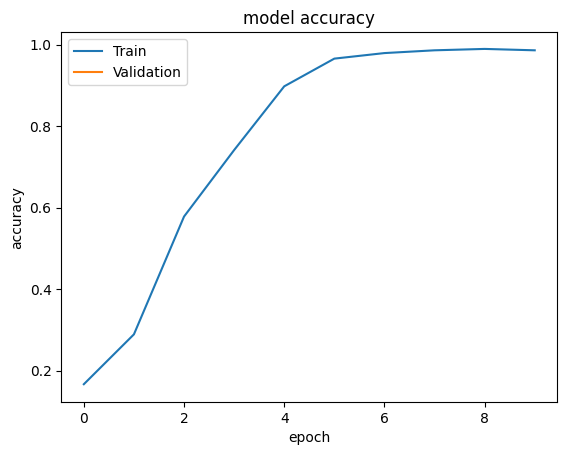

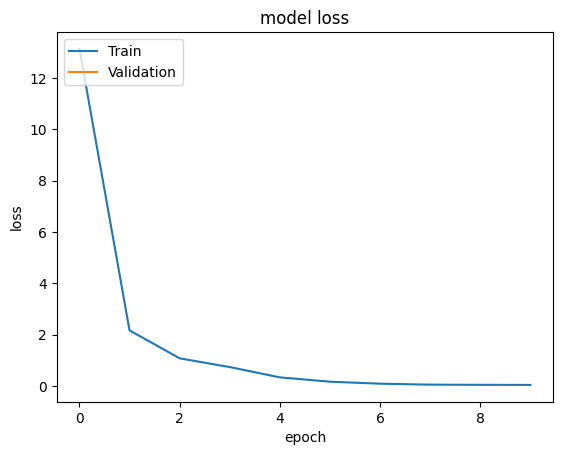

In [ ]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

[INFO] loading model and label binarizer..
1/1 [==============================] - 0s 166ms/step


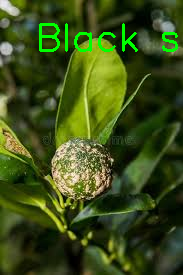

In [ ]:
from google.colab.patches import cv2_imshow
from tensorflow.keras.models import load_model
from collections import deque
import numpy as np
import argparse
import pickle
import cv2

print("[INFO] loading model and label binarizer..")
model = load_model('/content/model1.h5')
lb = pickle.loads(open('/content/Pickle_model1.pkl',"rb").read())
img = cv2.imread("/content/fruit_images/test/Scab/citrus fruit scab22.jpg")

output = img.copy()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img , (224,224)).astype("float32")
preds = model.predict(np.expand_dims(img,axis = 0))[0]

i = np.argmax(preds)
label = lb.classes_[i]
text = "{}".format(label)

cv2.putText(output,text,(35,50), cv2.FONT_HERSHEY_SIMPLEX, 1.25, (0,255,0),2)
cv2_imshow(output)
cv2.waitKey(0)
cv2.destroyAllWindows()